# 02 Feature Engineering — 입력 변수 만들기 · 고르기
- 원칙: 초기 100사이클(사이클 2 ~ 100) 값만 사용한다. 100사이클 이후는 예측 시점에 없는 미래 정보
- 피처를 고르는 근거는 **학습 배치(B1)에서만** 계산한다 (테스트 정보 차단)
- 계산 코드: `src/features.py` (셀 단위 피처 테이블 → `data/processed/features.csv`)

In [1]:
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import train as T
from config import CANDIDATES, CORE, EXCLUDED, FIG_DIR
from features import delta_q
from preprocess import load_cells
from sklearn.linear_model import LinearRegression

plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
b1, b2, b3 = T.load_data()
train, valid = T.split_holdout(b1)

## 1. 핵심 피처: ΔQ(V) 분산
- `Qdlin`: 사이클마다 방전 용량을 공통 전압 눈금(3.5 → 2.0V, 1,000점)에 맞춰 다시 찍은 값 → 다른 사이클끼리 같은 전압에서 뺄 수 있다
- **ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)**: 100번째와 10번째 사이클 방전 곡선의 차이
- **dq_var_log = log10( Var_V[ΔQ(V)] )**: 1,000개 전압 점에서의 분산 → 곡선 모양이 얼마나 변했는지를 숫자 하나로
- 용량 자체는 100사이클까지 거의 변하지 않지만(중앙값 +0.2%), 곡선 모양은 이미 셀마다 다르게 변해 있다

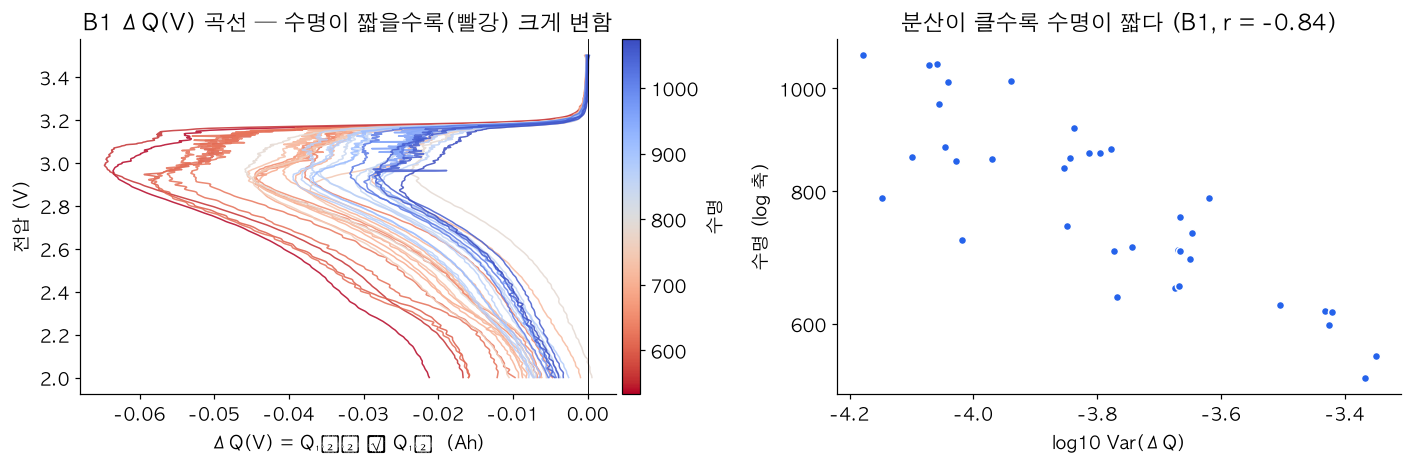

In [2]:
cells = {c['cell_id']: c for c in load_cells(['b1'])}
V = next(iter(cells.values()))['vdlin']
norm = mcolors.Normalize(b1.cycle_life.min(), b1.cycle_life.max())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for _, r in b1.sort_values('cycle_life').iterrows():
    ax[0].plot(delta_q(cells[r.cell_id]), V, color=cm.coolwarm_r(norm(r.cycle_life)), lw=1, alpha=0.85)
ax[0].axvline(0, color='black', lw=0.6); ax[0].set_xlabel('ΔQ(V) = Q₁₀₀ − Q₁₀  (Ah)'); ax[0].set_ylabel('전압 (V)')
ax[0].set_title('B1 ΔQ(V) 곡선 — 수명이 짧을수록(빨강) 크게 변함')
fig.colorbar(cm.ScalarMappable(norm=norm, cmap='coolwarm_r'), ax=ax[0], fraction=0.04, pad=0.01, label='수명')
r = np.corrcoef(b1.dq_var_log, b1.log_life)[0, 1]
ax[1].scatter(b1.dq_var_log, b1.cycle_life, color='#2563eb', s=28, edgecolor='white')
ax[1].set_yscale('log'); ax[1].set_yticks([600, 800, 1000]); ax[1].set_yticklabels(['600', '800', '1000']); ax[1].minorticks_off()
ax[1].set_xlabel('log10 Var(ΔQ)'); ax[1].set_ylabel('수명 (log 축)'); ax[1].set_title(f'분산이 클수록 수명이 짧다 (B1, r = {r:.2f})')
plt.tight_layout(); plt.savefig(FIG_DIR / 'f1_delta_q.png', dpi=200, bbox_inches='tight'); plt.show()

## 2. 피처 목록 — 확정 · 후보 · 제외 (1일차 EDA 결론)

In [3]:
desc = {'dq_var_log': '방전 곡선 변화 크기 (ΔQ 분산, log)', 'dq_skew': '곡선 변화의 비대칭도 (ΔQ 왜도)',
        'qd_slope_2_100': '초기 용량 감소 추세 (사이클 2 ~ 100 기울기)', 'ir_min': '내부 저항 최솟값 (B2 6셀 결측 → 학습 중앙값 대체)',
        'tavg_mean': '평균 온도 (사이클 2 ~ 100)', 'chargetime_2_6': '초기 충전 시간', 'qd_2': '초기 용량 (사이클 2)',
        'dq_min_log': 'ΔQ 최솟값 (log)', 'dq_mean_log': 'ΔQ 평균 (log)'}
tbl = pd.DataFrame([{'피처': f, '설명': desc[f], '구분': '확정'} for f in CORE] +
                   [{'피처': f, '설명': desc[f], '구분': '후보 (학습 CV로 결정)'} for f in CANDIDATES] +
                   [{'피처': f, '설명': desc[f], '구분': '제외 — ' + why} for f, why in EXCLUDED.items()])
tbl

,피처,설명,구분
0,dq_var_log,"방전 곡선 변화 크기 (ΔQ 분산, log)",확정
1,dq_skew,곡선 변화의 비대칭도 (ΔQ 왜도),후보 (학습 CV로 결정)
2,qd_slope_2_100,초기 용량 감소 추세 (사이클 2 ~ 100 기울기),후보 (학습 CV로 결정)
3,ir_min,내부 저항 최솟값 (B2 6셀 결측 → 학습 중앙값 대체),후보 (학습 CV로 결정)
4,tavg_mean,평균 온도 (사이클 2 ~ 100),후보 (학습 CV로 결정)
5,chargetime_2_6,초기 충전 시간,"제외 — ΔQ 분산과 중복 (학습 28셀: ΔQ 반영 후 남는 상관 0.05, 더하..."
6,qd_2,초기 용량 (사이클 2),제외 — 초기 용량 값은 수명별 차이 없음
7,dq_min_log,ΔQ 최솟값 (log),제외 — ΔQ 분산과 중복 (상관 1.00)
8,dq_mean_log,ΔQ 평균 (log),제외 — ΔQ 분산과 중복


## 3. 다중공선성 — 피처끼리 같은 정보를 담고 있나 (학습 28셀)
- VIF(분산 팽창 계수): 한 피처를 나머지 피처로 회귀했을 때 얼마나 잘 설명되는지. 5 ~ 10을 넘으면 같은 정보가 겹친다고 본다

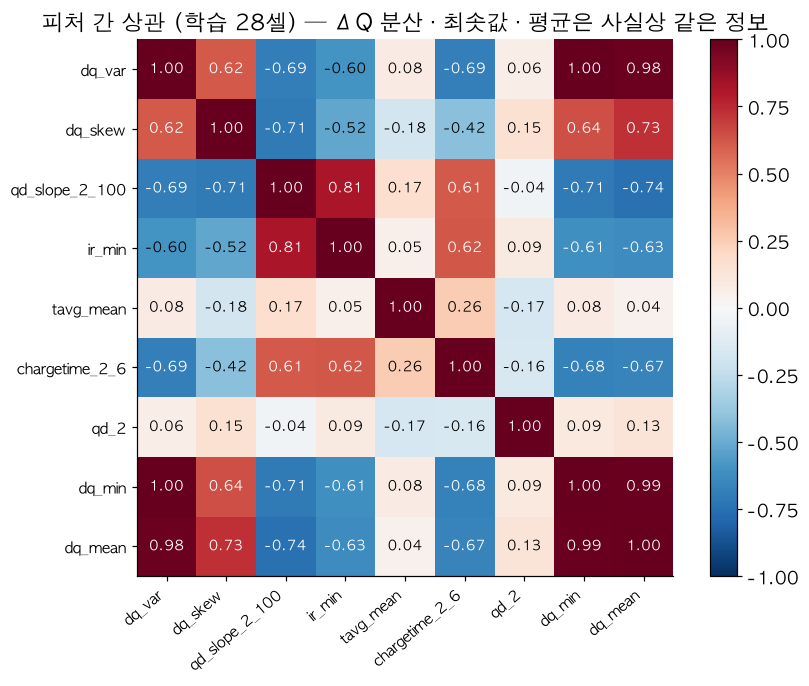

VIF — 확정 + 후보 (5 미만이면 공선성 문제 작음)
dq_var_log        2.27
dq_skew           2.24
qd_slope_2_100    4.90
ir_min            3.10
tavg_mean         1.17

VIF — ΔQ 계열 3개를 같이 넣으면
dq_var_log     234.4
dq_min_log     389.0
dq_mean_log     62.9


In [4]:
cols = CORE + CANDIDATES + list(EXCLUDED)
cm_ = train[cols].corr()
fig, ax = plt.subplots(figsize=(8, 6.4))
im = ax.imshow(cm_.values, cmap='RdBu_r', vmin=-1, vmax=1)
lab = [f.replace('_log', '') for f in cols]
ax.set_xticks(range(len(cols))); ax.set_xticklabels(lab, rotation=40, ha='right', fontsize=10)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(lab, fontsize=10)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = cm_.values[i, j]; ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9, color='white' if abs(v) > 0.6 else 'black')
ax.set_title('피처 간 상관 (학습 28셀) — ΔQ 분산 · 최솟값 · 평균은 사실상 같은 정보'); fig.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.savefig(FIG_DIR / 'f2_feature_corr.png', dpi=200, bbox_inches='tight'); plt.show()

def vif(df):
    X = (df - df.mean()) / df.std()
    return pd.Series([1 / (1 - LinearRegression().fit(X.drop(columns=c), X[c]).score(X.drop(columns=c), X[c])) for c in X], index=X.columns)
print('VIF — 확정 + 후보 (5 미만이면 공선성 문제 작음)'); print(vif(train[CORE + CANDIDATES].dropna()).round(2).to_string())
print('\nVIF — ΔQ 계열 3개를 같이 넣으면'); print(vif(train[['dq_var_log', 'dq_min_log', 'dq_mean_log']]).round(1).to_string())

## 4. 후보 피처 선택 — 학습 28셀 교차검증 (같은 충전 방식은 같은 fold)
ΔQ 분산에 후보 4개의 모든 조합(15가지)을 더해 선형회귀 교차검증 MAPE를 비교한다. 검증 · 테스트 셀은 쓰지 않는다.

In [5]:
rows = []
for name, feats, est in T.candidates():
    if T.family(name) != '선형회귀':
        continue
    p, folds = T.oof_predict(est, train[feats], train[T.TARGET], train.policy, train.cycle_life)
    rows.append({'추가한 후보': ' + '.join(feats[1:]) or '(없음: ΔQ 분산만)', '피처 수': len(feats),
                 'Train CV MAPE (fold 평균)': np.mean(folds), 'fold 표준편차': np.std(folds)})
sel = pd.DataFrame(rows).sort_values('Train CV MAPE (fold 평균)').reset_index(drop=True)
sel.round(2)

,추가한 후보,피처 수,Train CV MAPE (fold 평균),fold 표준편차
0,(없음: ΔQ 분산만),1,7.98,3.24
1,ir_min,2,8.25,3.33
2,tavg_mean,2,8.51,3.30
3,dq_skew,2,8.73,2.10
4,dq_skew + ir_min,3,9.01,2.30
5,ir_min + tavg_mean,3,9.11,3.28
6,dq_skew + tavg_mean,3,9.15,2.37
7,dq_skew + qd_slope_2_100,3,9.25,2.46
8,dq_skew + qd_slope_2_100 + tavg_mean,4,9.48,2.55
9,dq_skew + qd_slope_2_100 + ir_min,4,9.57,2.67


## 5. 충전 시간 재확인 — 학습 28셀만으로
테스트 배치의 충전 시간이 10분대로 몰려 있다는 이유만으로 빼면 "테스트를 보고 고른 것"이 된다. 그래서 학습 28셀 안에서
ΔQ 분산에 충전 시간을 더했을 때 교차검증 오차가 줄어드는지 따로 확인했다. (검증 8셀은 쓰지 않는다)

In [6]:
y = train[T.TARGET]
res = y - LinearRegression().fit(train[CORE], y).predict(train[CORE])
print('충전 시간 ↔ ΔQ 분산 상관 r = %.2f' % np.corrcoef(train.chargetime_2_6, train.dq_var_log)[0, 1])
print('ΔQ 분산을 반영한 뒤 남는 충전 시간의 상관 = %.2f' % np.corrcoef(train.chargetime_2_6, res)[0, 1])
for feats in (CORE, CORE + ['chargetime_2_6']):
    p, folds = T.oof_predict(T.pipe(LinearRegression()), train[feats], y, train.policy, train.cycle_life)
    print(f'{" + ".join(feats):30s} 학습 28셀 교차검증 MAPE (fold 평균) {np.mean(folds):.2f}%')

충전 시간 ↔ ΔQ 분산 상관 r = -0.69
ΔQ 분산을 반영한 뒤 남는 충전 시간의 상관 = 0.05
dq_var_log                     학습 28셀 교차검증 MAPE (fold 평균) 7.98%
dq_var_log + chargetime_2_6    학습 28셀 교차검증 MAPE (fold 평균) 8.37%


## 6. 예측 대상 변환 — log10(수명)
- 수명이 수백 ~ 2천 사이클로 넓고 오른쪽으로 긴 분포 → log를 취하면 오차가 수명에 비례하는 구조(MAPE)와 맞고, ΔQ 분산(log)과 직선 관계가 된다
- 예측값은 10^(예측)으로 되돌려 사이클 단위로 평가한다

## 정리
- **MAPE 기준 최선 입력 = ΔQ 분산 1개.** 학습 28셀 교차검증에서 후보 4개는 어떤 조합도 ΔQ 분산 하나보다 오차를 줄이지 못했다 (4절). 셀 28개로 개선이 확인되지 않았다는 뜻이지, 그 피처에 정보가 전혀 없다는 뜻은 아니다
- 손실 기준 선택(03 노트북)에서도 R ≥ 0.4 구간은 ΔQ 분산 1개짜리 모델이 뽑힌다. R ≤ 0.3에서는 후보를 더한 모델이 뽑힌다
- ΔQ 최솟값 · 평균은 분산과 상관 0.9 이상으로 같은 정보라 하나만 쓴다 (3절)
- 충전 시간은 ΔQ 분산을 반영하면 추가 정보가 거의 남지 않아 제외했다 (5절, 학습 배치만으로 확인)